# EMBER Package Example
Welcome to the **EMBER (Evacuation Mobility Behavior Inference)** package example notebook.

This notebook demonstrates how to load data, run the taxonomy classification engine, and generate metrics plots directly from the pip-installable `ember` library.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import ember


# Ensure plots display nicely inline
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load the Sample Data
EMBER's `io` module handles all coordinate reference system (CRS) projections seamlessly, converting any spatial data to standard `EPSG:4326`.

In [2]:
# Load 1000 sample inferred homes
homes_gdf = ember.io.load_homes('data_sample/sample_homes.csv')
print(f"Loaded {len(homes_gdf)} residents.")
homes_gdf.head(3)

Loaded 1000 residents.


,ID,home_lon_4326,home_lat_4326,num_nights,stay_time,geometry
0,c8dc7a41-2a12-39c2-8a5d-68a9fc417be8,-118.251282,34.152299,20,1739518.0,POINT (-118.25128 34.1523)
1,554c66e1-7191-34cd-93b2-ae4b83adf94d,-118.567558,34.157234,16,1494501.0,POINT (-118.56756 34.15723)
2,46b96c44-f61b-33f2-952c-d0640a123cd8,-118.523305,34.169514,15,1412327.0,POINT (-118.5233 34.16951)


In [3]:
# Load actual Evacuation perimeters (Order / Warning areas)
zones_gdf = ember.io.load_fire_timeline('data_sample/Fire_Timeline_Sample/')
print(f"Loaded {len(zones_gdf)} unique evacuation zone polygons.")

Loaded 9 unique evacuation zone polygons.


## 2. Spatial Join: Homes to Zones
We use the `zones` module to figure out exactly which evacuation zone each resident lived in when the order was issued.

In [4]:
homes_with_zones = ember.zones.classify_zones(
    homes_gdf, 
    zones_gdf, 
    buffer_distance=1000.0, # 1km Buffer zone for Shadow evacuees
    order_status="Evacuation Order",
    warning_status="Evacuation Warning"
)
homes_with_zones['ZoneType'].value_counts()

ZoneType
Outside    990
Buffer       9
Order        1
Name: count, dtype: int64

## 3. Taxonomy Classification
Assuming we've run `ember.departure.infer()` on GPS tracks (or we loaded pre-processed departure intervals), we now run the 7-Category taxonomy rule engine.

In [5]:
# Load pre-computed departure/return metrics for the sample
metrics = ember.io.load_evacuation_metrics('data_sample/sample_evacuation_metrics.csv')

import numpy as np
# Reconstruct Fire/Order temporal boundaries for the classification rules
metrics['FireStart'] = np.where(
    metrics['ZoneType'].str.contains('Palisades', na=False), # Example fallback
    pd.to_datetime("2025-01-07 10:30:00"),
    pd.to_datetime("2025-01-07 18:18:00")
)
metrics['OrderEnd'] = pd.to_datetime('2025-01-14 23:00:00')

# ---------------------------------------------------------
# THE CORE ENGINE
# ---------------------------------------------------------
metrics['Category'] = ember.behavior.classify(
    metrics,
    zone_col='ZoneType',
    departure_col='DepartureDate',
    return_col='ReturnDate',
    order_start_col='OrderStart',
    order_end_col='OrderEnd',
    fire_start_col='FireStart'
)

# Show human-readable summary table
ember.behavior.summary(metrics['Category'])

,Category,Count,Percentage,Description
5,SELE,2,1.37,Self-Evacuee Leaving Early
2,PERE,14,9.59,Partially-compliant Evacuee (Early Returner)
4,FEUO,3,2.05,Fully-compliant Evacuee Under Order
3,FEUW,4,2.74,Fully-compliant Evacuee Under Warning
1,SEFN,19,13.01,Shadow Evacuee From Nearby
0,NER,104,71.23,Non-Evacuee Resident
6,UR,0,0.00,Uncategorized Resident


## 4. Evacuation Metrics & Curves
Calculate the Compliance Rate and plot the cumulative departure flow.

In [6]:
compl = ember.metrics.compliance_rate(metrics)
display(compl)

,ZoneType,Total_Residents,Evacuated,Compliance_Rate
0,Buffer,72.0,19.0,0.263889
1,Order,45.0,13.0,0.288889
2,Warning,29.0,10.0,0.344828


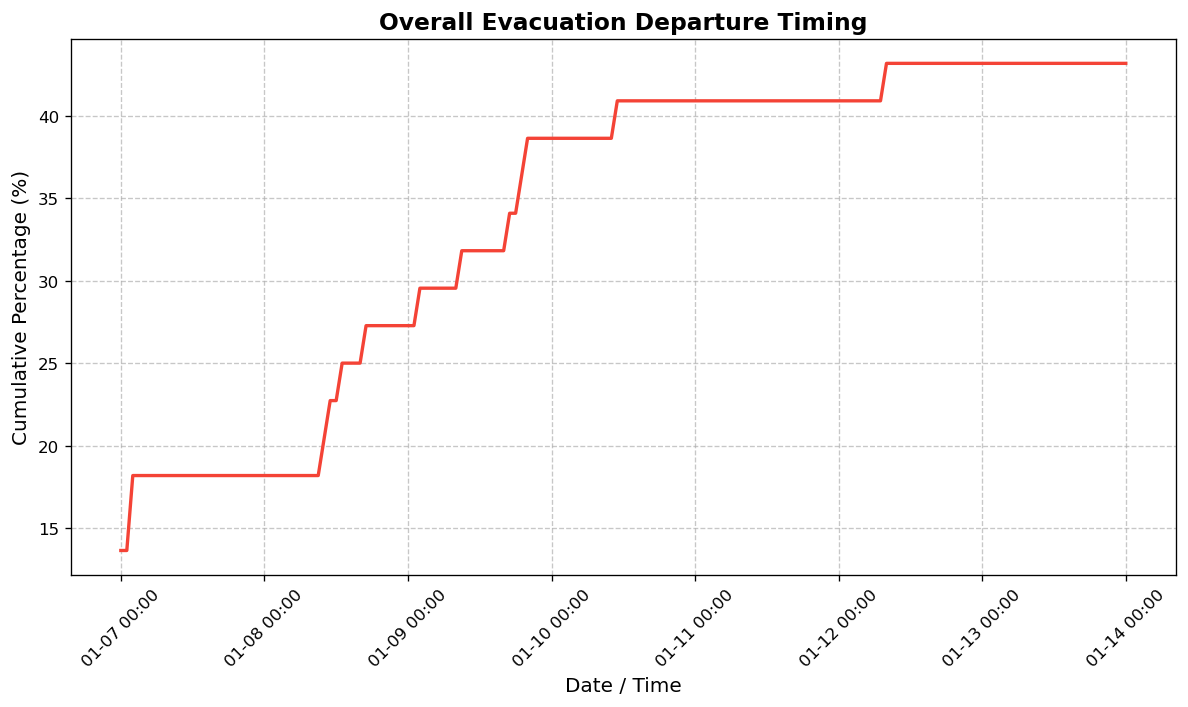

/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/../ember/metrics.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props = subset.groupby([group_col, 'Category']).size().reset_index(name='count')
/Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/../ember/metrics.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  props = subset.groupby([group_col, 'Category']).size().reset_index(name='count')


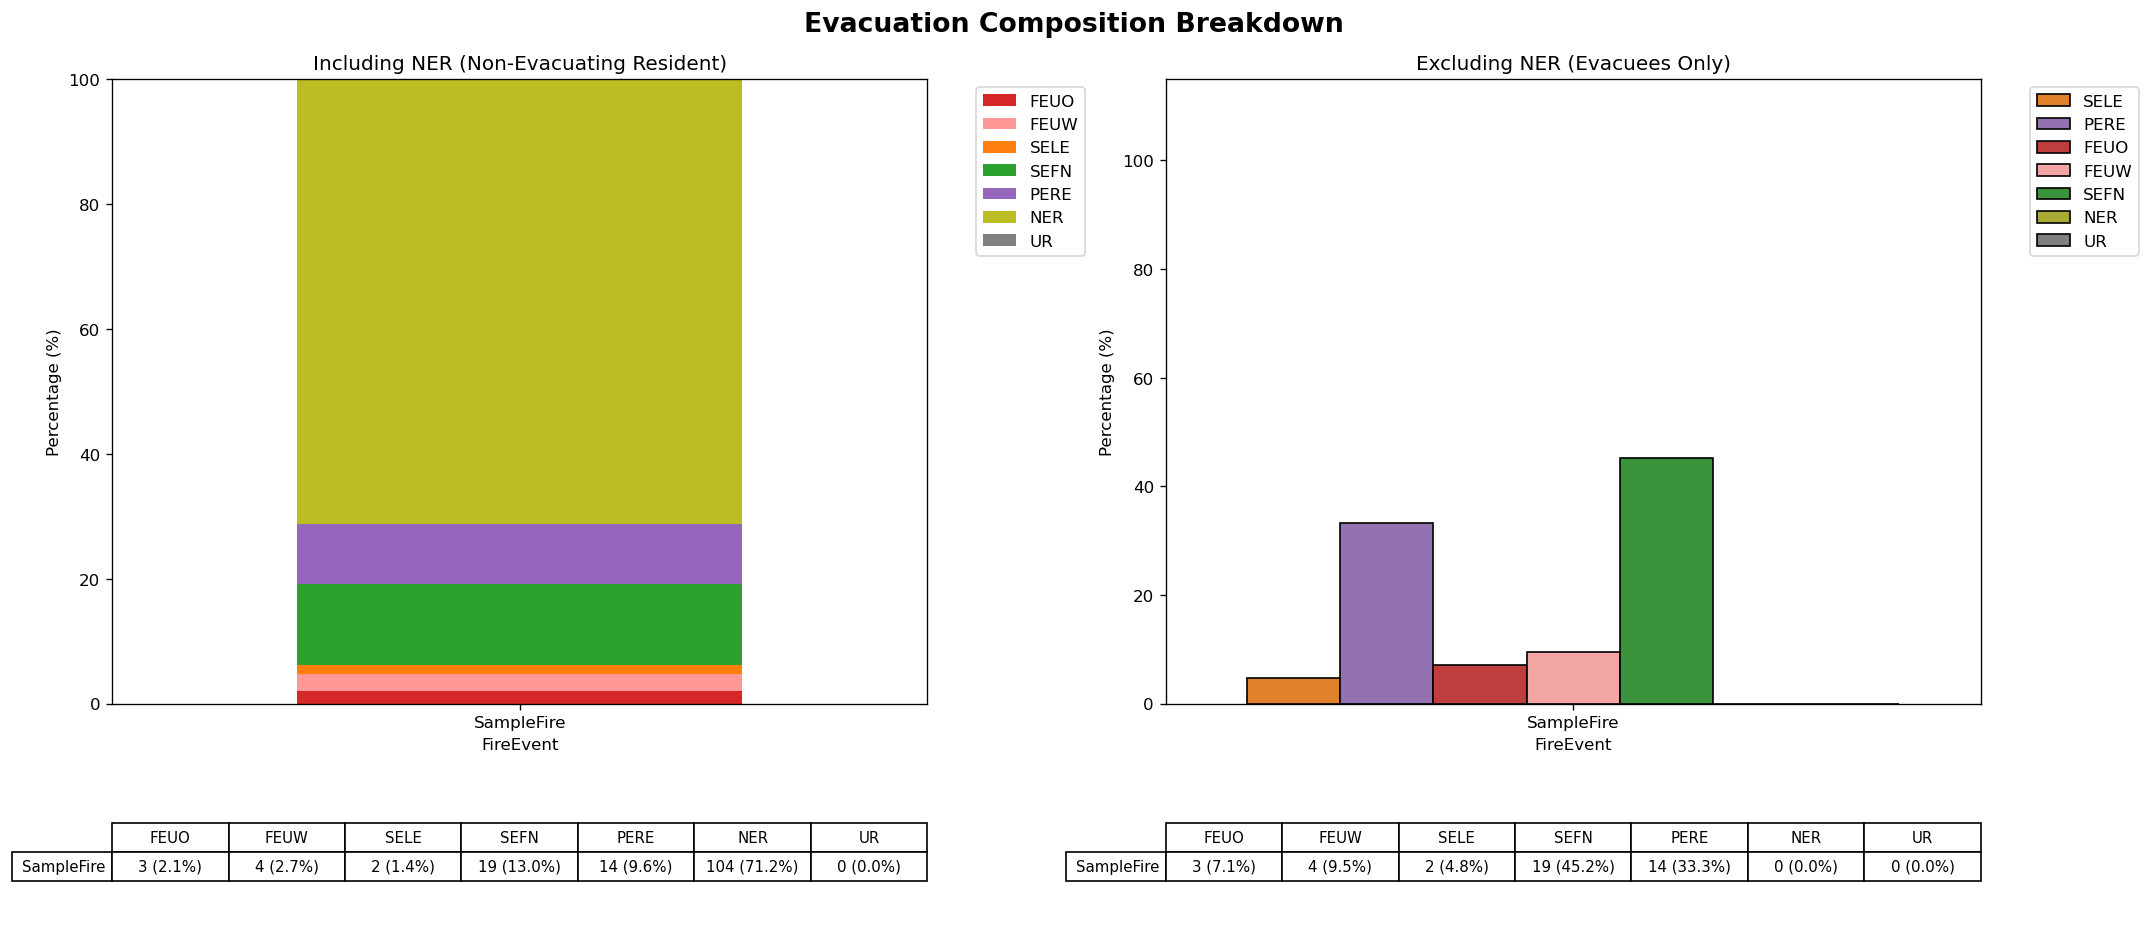

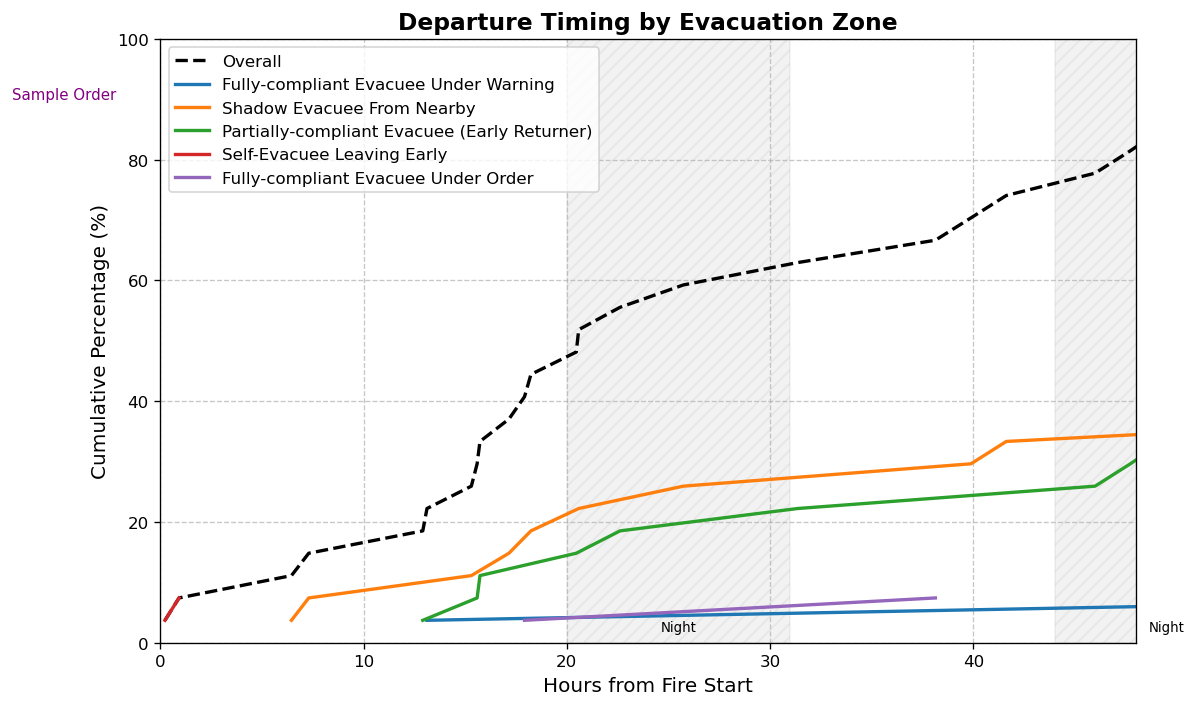

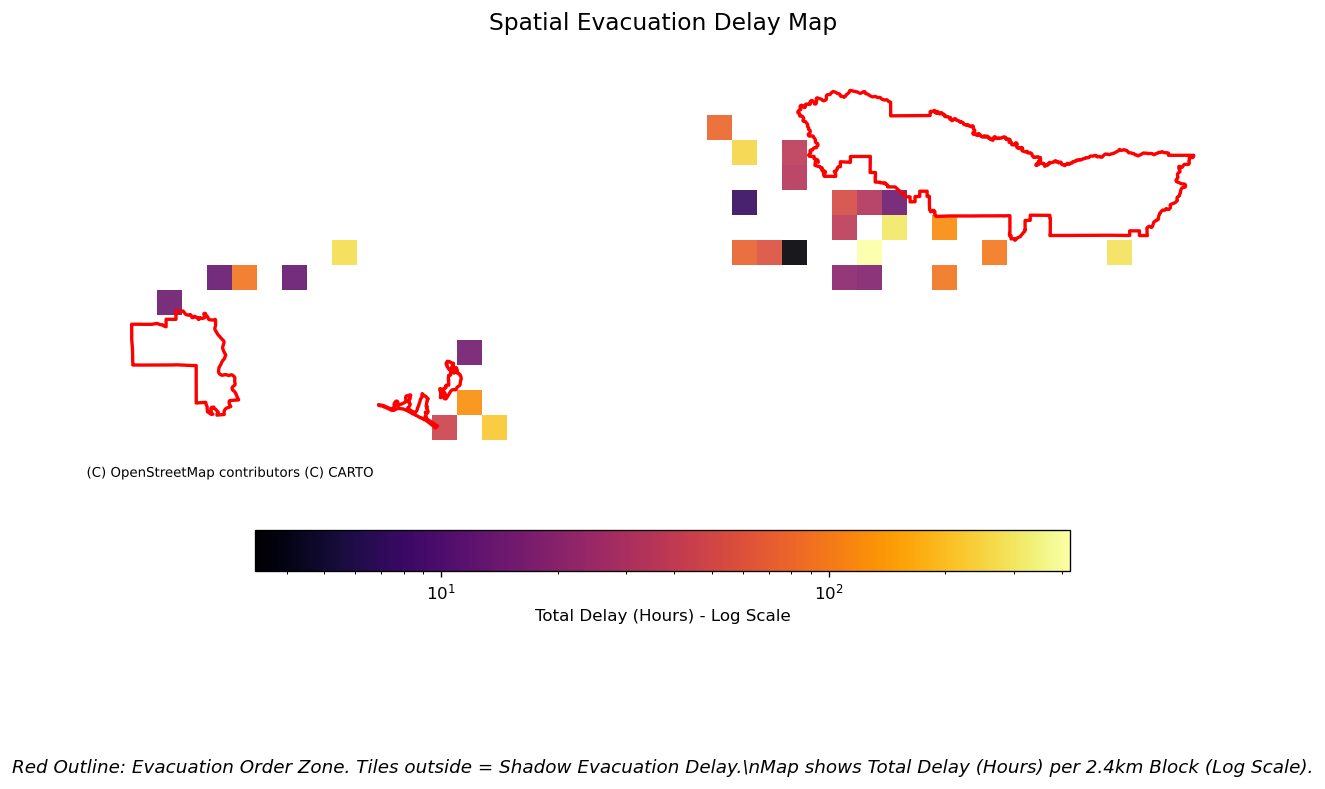

In [7]:
# 1. Plot Overall Departure Curve
target_zone = "Order"
curve_data = ember.metrics.departure_curve(
    metrics[metrics.Category != 'SELE'],
    start="2025-01-07 00:00:00", end="2025-01-14 00:00:00", freq="1h", zone=target_zone
)
ember.metrics.plot_departure_curve(curve_df=curve_data, title="Overall Evacuation Departure Timing")

# 2. Plot Evacuation Composition
metrics['FireEvent'] = 'SampleFire'
ember.metrics.plot_evacuation_composition(metrics, group_col='FireEvent', dual_panel=True, title="Evacuation Composition Breakdown")

# 3. Plot Departure Curve by Zone
metrics['Fig10_Group'] = metrics['Category'].map(ember.behavior.CATEGORY_NAMES)
start_ref = pd.to_datetime(metrics['FireStart']).min()
order_min = pd.to_datetime(metrics['OrderStart']).dropna().min()
order_offsets = {'Sample': (order_min - start_ref).total_seconds() / 3600.0} if pd.notnull(order_min) else None
night_shades = [(20, 31), (44, 55)]

ember.metrics.plot_departure_curve(
    df=metrics, start_ref=start_ref, order_offsets=order_offsets, night_shades=night_shades, group_col='Fig10_Group', title="Departure Timing by Evacuation Zone"
)

# 4. Plot Spatial Delay Map
home_coords = homes_gdf.set_index('ID')[['home_lat_4326', 'home_lon_4326']]
metrics = metrics.join(home_coords, on='ID')
metrics['DelayHours'] = (pd.to_datetime(metrics['DepartureDate']) - pd.to_datetime(metrics['OrderStart'])).dt.total_seconds() / 3600.0

ember.metrics.plot_delay_map(metrics, zones_gdf, title="Spatial Evacuation Delay Map")
